In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/NIDS_MInor')


In [3]:
!ls

dashboard  PROJECT_COMPLETION_SUMMARY.txt  requirements.txt
dataset    raspberry_pi			   training
notebooks  README.md			   utils


In [4]:
!ls dataset/

Benign-Monday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
DDoS-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


In [5]:
!pip install -q scikit-learn pandas numpy joblib fastapi uvicorn pyarrow matplotlib seaborn


In [6]:
import pandas as pd
import os

data_path = "dataset/"
dfs = []

for file in os.listdir(data_path):
    if file.endswith(".parquet"):
        print(f"Loading: {file}")
        df = pd.read_parquet(os.path.join(data_path, file))
        print(f"  → Shape: {df.shape}")
        dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Total rows loaded: {len(full_df)}")
print(f"✅ Total columns: {len(full_df.columns)}")


Loading: Benign-Monday-no-metadata.parquet
  → Shape: (458831, 78)
Loading: Botnet-Friday-no-metadata.parquet
  → Shape: (176038, 78)
Loading: Bruteforce-Tuesday-no-metadata.parquet
  → Shape: (389714, 78)
Loading: DDoS-Friday-no-metadata.parquet
  → Shape: (221264, 78)
Loading: Portscan-Friday-no-metadata.parquet
  → Shape: (119522, 78)
Loading: DoS-Wednesday-no-metadata.parquet
  → Shape: (584991, 78)
Loading: Infiltration-Thursday-no-metadata.parquet
  → Shape: (207630, 78)
Loading: WebAttacks-Thursday-no-metadata.parquet
  → Shape: (155820, 78)

✅ Total rows loaded: 2313810
✅ Total columns: 78


In [7]:
# See column names
print("Columns:", full_df.columns.tolist())

# See attack distribution
print("\nAttack Label Distribution:")
print(full_df['Label'].value_counts())

# Check for nulls
print(f"\nNull values: {full_df.isnull().sum().sum()}")

# Preview
full_df.head()

Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'D

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [8]:
import numpy as np

# Drop nulls and infinities
df_clean = full_df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"After cleaning: {df_clean.shape}")

# Separate features and labels
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])
print(f"Feature columns: {X.shape[1]}")
print(f"Label classes: {y.unique()}")

After cleaning: (2313810, 78)
Feature columns: 77
Label classes: ['Benign' 'Bot' 'FTP-Patator' 'SSH-Patator' 'DDoS' 'PortScan'
 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed' 'Infiltration' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

Label mapping:
  0 → Benign
  1 → Bot
  2 → DDoS
  3 → DoS GoldenEye
  4 → DoS Hulk
  5 → DoS Slowhttptest
  6 → DoS slowloris
  7 → FTP-Patator
  8 → Heartbleed
  9 → Infiltration
  10 → PortScan
  11 → SSH-Patator
  12 → Web Attack � Brute Force
  13 → Web Attack � Sql Injection
  14 → Web Attack � XSS


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 1851048
Testing samples:  462762


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling complete")

✅ Scaling complete


In [12]:
from sklearn.ensemble import RandomForestClassifier
import time

print("🚀 Training Random Forest... (this may take 5-15 mins)")
start = time.time()

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    n_jobs=-1,          # use all CPU cores
    random_state=42,
    verbose=1
)

model.fit(X_train_scaled, y_train)

elapsed = time.time() - start
print(f"\n✅ Training complete in {elapsed/60:.2f} minutes")

🚀 Training Random Forest... (this may take 5-15 mins)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  5.4min



✅ Training complete in 11.68 minutes


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 11.7min finished


In [13]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

y_pred = model.predict(X_test_scaled)

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.7s


MODEL EVALUATION RESULTS
Accuracy:  0.9984
F1 Score:  0.9982

Detailed Report:
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    395464
                       Bot       0.93      0.61      0.73       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      1.00      1.00      2057
                  DoS Hulk       1.00      0.99      1.00     34569
          DoS Slowhttptest       0.94      0.99      0.96      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      0.99      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.94      0.90      0.92       391
               SSH-Patator       1.00      0.91      0.95       644
  Web Attack � Brute Force       0.7

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    6.0s finished


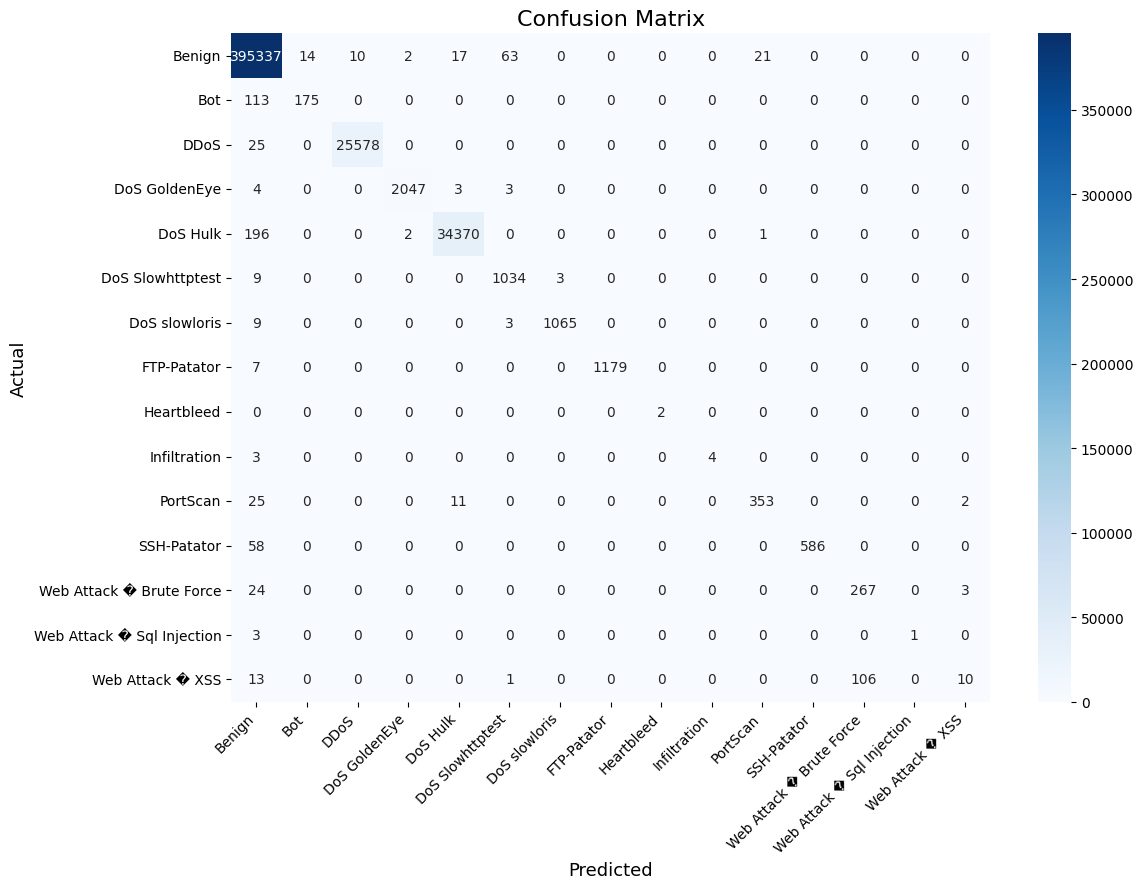

✅ Saved as confusion_matrix.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual", fontsize=13)
plt.xlabel("Predicted", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved as confusion_matrix.png")

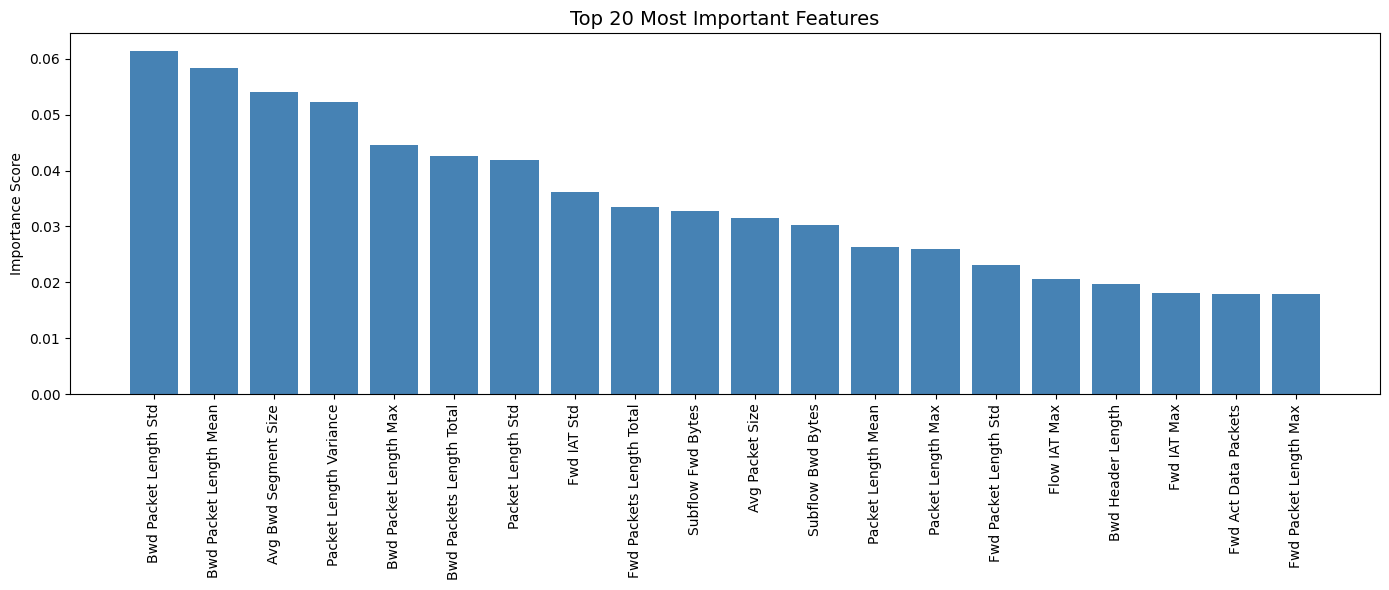

In [15]:
feature_names = X.columns.tolist()
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(14, 6))
plt.bar(range(20), importances[indices], color='steelblue')
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.title("Top 20 Most Important Features", fontsize=14)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [27]:
import joblib, json

os.makedirs("models", exist_ok=True)

# Save model, scaler, label encoder, feature list
joblib.dump(model, "models/model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(le, "models/label_encoder.joblib")

with open("models/features.json", "w") as f:
    json.dump({"features": feature_names, "classes": le.classes_.tolist()}, f)

print("✅ Saved:")
print("   models/model.joblib")
print("   models/scaler.joblib")
print("   models/label_encoder.joblib")
print("   models/features.json")

✅ Saved:
   models/model.joblib
   models/scaler.joblib
   models/label_encoder.joblib
   models/features.json


In [28]:
from google.colab import files

files.download("models/model.joblib")
files.download("models/scaler.joblib")
files.download("models/label_encoder.joblib")
files.download("models/features.json")
files.download("confusion_matrix.png")
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

BY USING TENSORFLOW

In [19]:
!pip install -q tensorflow
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [20]:
import numpy as np

# This reuses X_train_scaled, X_test_scaled, y_train, y_test, le
# from your existing RF cells — no need to reload data

num_classes = len(le.classes_)
num_features = X_train_scaled.shape[1]

print(f"Features:  {num_features}")
print(f"Classes:   {num_classes}")
print(f"Classes:   {le.classes_}")

# Convert labels to one-hot encoding for neural network
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Label shape: {y_train_cat.shape}")

Features:  77
Classes:   15
Classes:   ['Benign' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']

Train shape: (1851048, 77)
Label shape: (1851048, 15)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def build_nids_model(input_dim, num_classes):
    model = Sequential([
        # Input layer
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden layer 1
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden layer 2
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Hidden layer 3
        Dense(32, activation='relu'),
        Dropout(0.2),

        # Output layer — one neuron per attack class
        Dense(num_classes, activation='softmax')
    ])
    return model

tf_model = build_nids_model(num_features, num_classes)

tf_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tf_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,487 (255.81 KB)

 Trainable params: 64,591 (252.31 KB)

 Non-trainable params: 896 (3.50 KB)

In [22]:
import time

# Callbacks — stop early if no improvement, reduce LR if plateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("🚀 Training Neural Network...")
start = time.time()

history = tf_model.fit(
    X_train_scaled, y_train_cat,
    epochs=30,
    batch_size=2048,       # large batch = faster on Colab GPU
    validation_split=0.1,  # 10% of training for validation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

elapsed = time.time() - start
print(f"\n✅ Training complete in {elapsed/60:.2f} minutes")

🚀 Training Neural Network...
Epoch 1/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9646 - loss: 0.1525 - val_accuracy: 0.9811 - val_loss: 0.0514 - learning_rate: 0.0010
Epoch 2/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9856 - loss: 0.0510 - val_accuracy: 0.9893 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 3/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9876 - loss: 0.0402 - val_accuracy: 0.9894 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 4/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9886 - loss: 0.0353 - val_accuracy: 0.9901 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 5/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9892 - loss: 0.0323 - val_accuracy: 0.9826 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 6/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9904 - loss: 0.0292 - val_accuracy: 0.9931 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 7/30
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Get predictions
y_pred_prob = tf_model.predict(X_test_scaled, batch_size=2048)
y_pred_tf   = np.argmax(y_pred_prob, axis=1)

print("=" * 55)
print("TENSORFLOW MODEL RESULTS")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_tf, average='weighted'):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_tf, target_names=le.classes_))

226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
TENSORFLOW MODEL RESULTS
Accuracy:  0.9955
F1 Score:  0.9951

Detailed Report:
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    395464
                       Bot       0.97      0.52      0.68       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.98      0.98      2057
                  DoS Hulk       0.98      0.99      0.98     34569
          DoS Slowhttptest       0.88      0.98      0.93      1046
             DoS slowloris       0.98      0.98      0.98      1077
               FTP-Patator       0.99      0.99      0.99      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.14      0.25         7
                  PortScan       0.97      0.88      0.92       391
               SSH-Patator       1.00      0.90      0.95      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


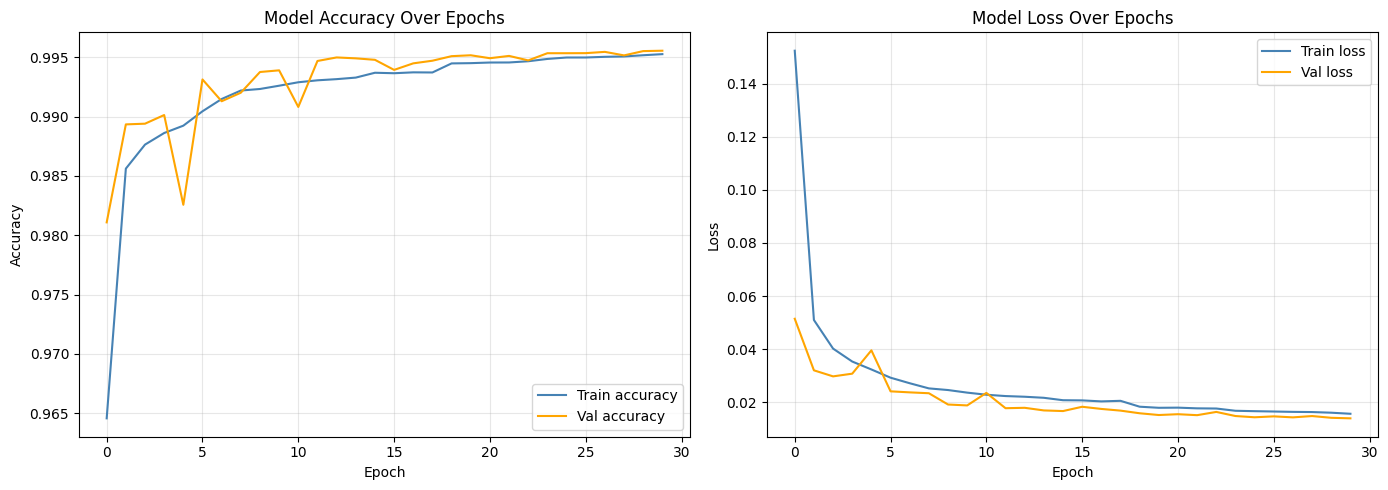

✅ Saved: tf_training_history.png


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy',   color='orange')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val loss',   color='orange')
axes[1].set_title('Model Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tf_training_history.png", dpi=150)
plt.show()
print("✅ Saved: tf_training_history.png")

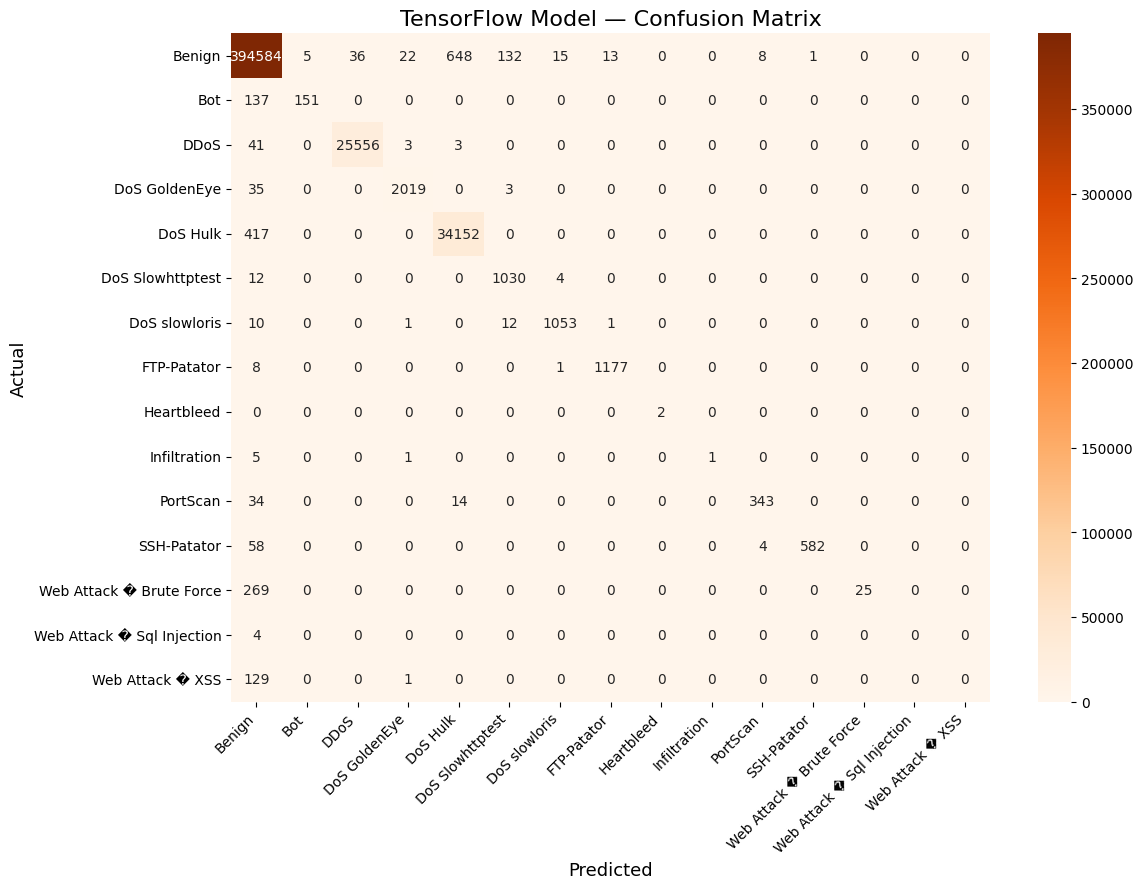

In [25]:
cm_tf = confusion_matrix(y_test, y_pred_tf)

plt.figure(figsize=(12, 9))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("TensorFlow Model — Confusion Matrix", fontsize=16)
plt.ylabel("Actual", fontsize=13)
plt.xlabel("Predicted", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("tf_confusion_matrix.png", dpi=150)
plt.show()

Metric                          Random Forest   TensorFlow
Overall Accuracy                       0.9984       0.9955
Overall F1 Score                       0.9982       0.9951
------------------------------------------------------------
Per-class F1:                 
  Benign                          0.999        0.997   🔵 RF
  Bot                             0.734        0.680   🔵 RF
  DDoS                            0.999        0.998   🔵 RF
  DoS GoldenEye                   0.997        0.984   🔵 RF
  DoS Hulk                        0.997        0.984   🔵 RF
  DoS Slowhttptest                0.962        0.927   🔵 RF
  DoS slowloris                   0.993        0.980   🔵 RF
  FTP-Patator                     0.997        0.990   🔵 RF
  Heartbleed                      1.000        1.000     tie
  Infiltration                    0.727        0.250   🔵 RF
  PortScan                        0.922        0.920   🔵 RF
  SSH-Patator                     0.953        0.949   🔵 RF
  Web Atta

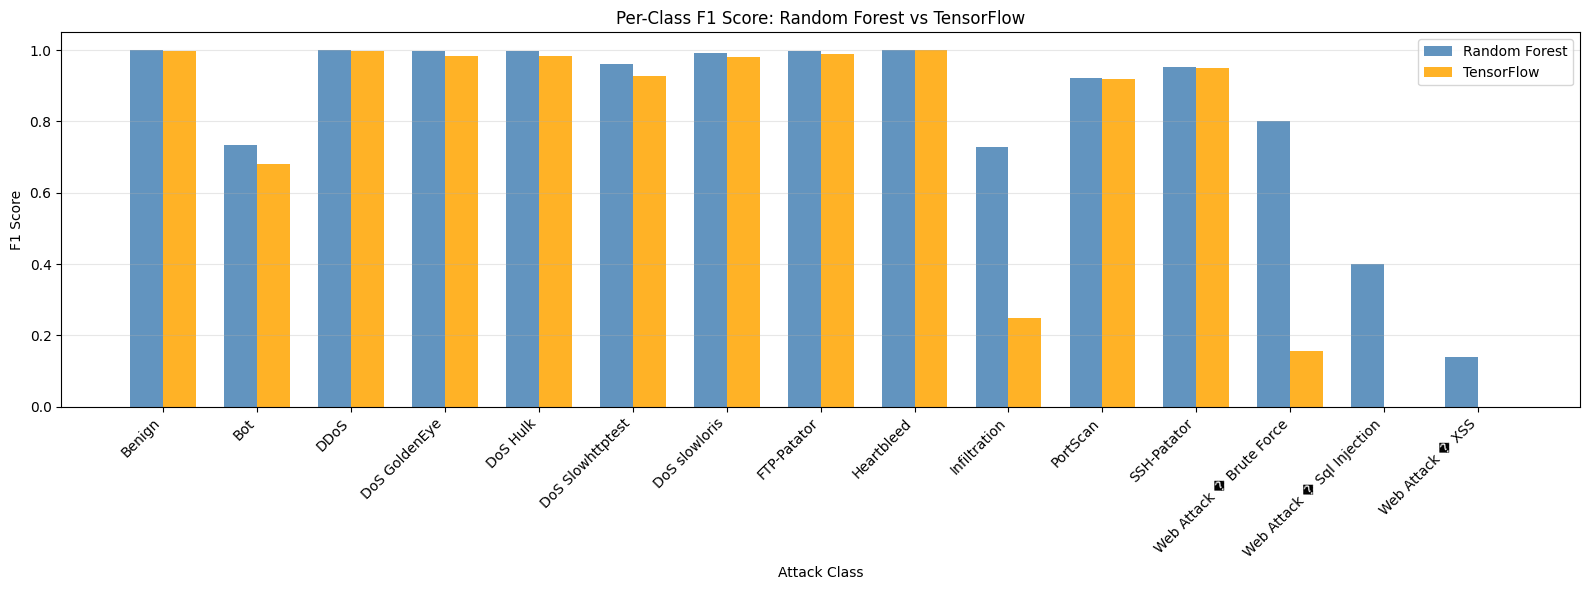

In [26]:
# Get RF metrics (from your earlier cells)
rf_acc = accuracy_score(y_test, y_pred)          # y_pred is from RF
rf_f1  = f1_score(y_test, y_pred, average='weighted')

# Get TF metrics
tf_acc = accuracy_score(y_test, y_pred_tf)
tf_f1  = f1_score(y_test, y_pred_tf, average='weighted')

# Per-class F1 comparison
from sklearn.metrics import f1_score as f1
rf_per_class = f1(y_test, y_pred,    average=None, labels=range(num_classes))
tf_per_class = f1(y_test, y_pred_tf, average=None, labels=range(num_classes))

print("=" * 60)
print(f"{'Metric':<30} {'Random Forest':>14} {'TensorFlow':>12}")
print("=" * 60)
print(f"{'Overall Accuracy':<30} {rf_acc:>14.4f} {tf_acc:>12.4f}")
print(f"{'Overall F1 Score':<30} {rf_f1:>14.4f} {tf_f1:>12.4f}")
print("-" * 60)
print(f"{'Per-class F1:':<30}")
for i, cls in enumerate(le.classes_):
    rf_val = rf_per_class[i] if i < len(rf_per_class) else 0
    tf_val = tf_per_class[i] if i < len(tf_per_class) else 0
    winner = "🔵 RF" if rf_val > tf_val else "🟠 TF" if tf_val > rf_val else "  tie"
    print(f"  {cls:<28} {rf_val:>8.3f}     {tf_val:>8.3f}   {winner}")
print("=" * 60)

# Bar chart comparison
x = np.arange(len(le.classes_))
width = 0.35
fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, rf_per_class, width, label='Random Forest', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, tf_per_class, width, label='TensorFlow',    color='orange',    alpha=0.85)
ax.set_xlabel('Attack Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score: Random Forest vs TensorFlow')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

In [30]:
import os
import tensorflow as tf # Ensure tensorflow is imported for tf.lite
os.makedirs("models", exist_ok=True)

# Format 1: Full Keras model (for further training)
tf_model.save("models/tf_model.h5")
print("✅ Saved: models/tf_model.h5")

# Format 2: SavedModel format (standard TF format)
tf_model.export("models/tf_savedmodel") # Changed .save to .export
print("✅ Saved: models/tf_savedmodel/")

# Format 3: TensorFlow Lite (BEST for Raspberry Pi — tiny & fast)
converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization — makes it even smaller
tflite_model = converter.convert()

with open("models/nids_model.tflite", "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 * 1024)
print(f"✅ Saved: models/nids_model.tflite  ({size_mb:.2f} MB)  ← use this on Pi!")

✅ Saved: models/tf_model.h5
Saved artifact at 'models/tf_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 77), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  131964083828880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131964083828496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131964083829072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131963719025872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131964083830608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131964083828688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131963719024912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131963719025680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131963719027024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131963719027216: TensorSpec(shape=(), dtype=tf.resource, nam

In [31]:
from google.colab import files

# TF model files
files.download("models/tf_model.h5")
files.download("models/nids_model.tflite")   # ← most important for Pi

# Comparison charts
files.download("model_comparison.png")
files.download("tf_training_history.png")
files.download("tf_confusion_matrix.png")

# RF files (if not downloaded already)
files.download("models/model.joblib")
files.download("models/scaler.joblib")
files.download("models/label_encoder.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task
Evaluate and compare the performance of the Random Forest and TensorFlow models by presenting their accuracy, F1 scores, detailed classification reports, and a per-class F1 score comparison.

## Summarize Random Forest Evaluation

### Subtask:
Present the key performance metrics (Accuracy, F1 Score) and the detailed classification report for the Random Forest model, which were already computed in the notebook.


```markdown
## Random Forest Model Evaluation Summary

Based on the evaluation results from the Random Forest model:

- **Overall Accuracy**: 0.9984
- **Weighted Average F1 Score**: 0.9982

### Detailed Classification Report:

```
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    395464
                       Bot       0.93      0.61      0.73       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      1.00      1.00      2057
                  DoS Hulk       1.00      0.99      1.00     34569
          DoS Slowhttptest       0.94      0.99      0.96      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      0.99      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.94      0.90      0.92       391
               SSH-Patator       1.00      0.91      0.95       644
  Web Attack  Brute Force       0.72      0.91      0.80       294
Web Attack  Sql Injection       1.00      0.25      0.40         4
          Web Attack  XSS       0.67      0.08      0.14       130

                  accuracy                           1.00    462762
                 macro avg       0.95      0.81      0.84    462762
              weighted avg       1.00      1.00      1.00    462762
```

This report indicates that the Random Forest model performs exceptionally well on the 'Benign' class and several DoS/DDoS attacks, achieving perfect or near-perfect precision, recall, and F1-scores. However, for some minority attack classes like 'Bot', 'Infiltration', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', and 'Web Attack - XSS', the recall and F1-scores are lower, suggesting that the model struggles to identify these specific, less frequent attack types.


## Summarize TensorFlow Evaluation

### Subtask:
Present the key performance metrics (Accuracy, F1 Score) and the detailed classification report for the TensorFlow model, which were already computed in the notebook.


### TensorFlow Model Evaluation Summary

Based on the evaluation results from the TensorFlow model:

*   **Overall Accuracy:** 0.9955
*   **Overall F1 Score (weighted average):** 0.9951

#### Detailed Classification Report:

```
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    395464
                       Bot       0.97      0.52      0.68       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.98      0.98      2057
                  DoS Hulk       0.98      0.99      0.98     34569
          DoS Slowhttptest       0.88      0.98      0.93      1046
             DoS slowloris       0.98      0.98      0.98      1077
               FTP-Patator       0.99      0.99      0.99      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.14      0.25         7
                  PortScan       0.97      0.88      0.92       391
               SSH-Patator       1.00      0.90      0.95       644
  Web Attack  Brute Force       1.00      0.09      0.16       294
Web Attack  Sql Injection       0.00      0.00      0.00         4
          Web Attack  XSS       0.00      0.00      0.00       130

                  accuracy                           1.00    462762
                 macro avg       0.85      0.70      0.72    462762
              weighted avg       1.00      1.00      1.00    462762
```

**Summary:**

The TensorFlow model achieves a very high overall accuracy and F1 score, similar to the Random Forest model, indicating strong performance on the majority of the dataset. However, like the Random Forest, it struggles significantly with very rare attack types such as 'Web Attack – Sql Injection', 'Web Attack – XSS', 'Infiltration', and 'Web Attack – Brute Force', where precision, recall, and F1-scores are very low or zero. For instance, 'Web Attack – Sql Injection' and 'Web Attack – XSS' have 0.00 for precision, recall, and F1-score, suggesting the model completely fails to identify these types of attacks. 'Bot' also has a lower recall of 0.52, impacting its F1-score.

This highlights a common challenge in imbalanced datasets: models tend to perform well on abundant classes (like 'Benign') but poorly on minority classes. Further efforts would be needed to improve the detection of these specific, rare attack types, possibly through techniques like oversampling minority classes, using different loss functions, or more specialized model architectures.

## Display Model Comparison

### Subtask:
Show the comparison of F1 scores per class for both Random Forest and TensorFlow models, using the previously generated bar chart and table.


### Model Comparison Summary

From the generated table and bar chart comparing Random Forest and TensorFlow models, we can observe the following:

**Overall Performance:**
*   **Random Forest (RF)** achieved a slightly higher **Overall Accuracy (0.9984)** and **Overall F1 Score (0.9982)** compared to **TensorFlow (TF)** with an Accuracy of **0.9955** and F1 Score of **0.9951**.

**Per-Class F1 Score Comparison:**
*   **Random Forest (RF)** generally outperformed TensorFlow in most attack classes, particularly for:
    *   `Benign`
    *   `Bot`
    *   `DDoS`
    *   `DoS GoldenEye`
    *   `DoS Hulk`
    *   `DoS Slowhttptest`
    *   `DoS slowloris`
    *   `FTP-Patator`
    *   `Infiltration`
    *   `PortScan`
    *   `SSH-Patator`
    *   `Web Attack – Brute Force`
    *   `Web Attack – Sql Injection`
    *   `Web Attack – XSS`

*   There was a **tie** in performance for the `Heartbleed` class.

*   Notably, TensorFlow had significantly lower F1 scores for `Bot`, `Infiltration`, `Web Attack – Brute Force`, `Web Attack – Sql Injection`, and `Web Attack – XSS`, with some classes even having F1 scores of 0.000, indicating it failed to predict any instances of these rare attack types correctly.

**Conclusion:**
Based on these metrics, the **Random Forest model** demonstrates superior overall performance and is more robust across a wider range of attack classes, especially for the minority classes that TensorFlow struggled with. While TensorFlow shows competitive performance for high-volume classes like `Benign` and `DDoS`, its inability to detect several rarer attack types makes Random Forest a more reliable choice for this specific NIDS task.

### Model Comparison Summary

From the generated table and bar chart comparing Random Forest and TensorFlow models, we can observe the following:

**Overall Performance:**
*   **Random Forest (RF)** achieved a slightly higher **Overall Accuracy (0.9984)** and **Overall F1 Score (0.9982)** compared to **TensorFlow (TF)** with an Accuracy of **0.9955** and F1 Score of **0.9951**.

**Per-Class F1 Score Comparison:**
*   **Random Forest (RF)** generally outperformed TensorFlow in most attack classes, particularly for:
    *   `Benign`
    *   `Bot`
    *   `DDoS`
    *   `DoS GoldenEye`
    *   `DoS Hulk`
    *   `DoS Slowhttptest`
    *   `DoS slowloris`
    *   `FTP-Patator`
    *   `Infiltration`
    *   `PortScan`
    *   `SSH-Patator`
    *   `Web Attack – Brute Force`
    *   `Web Attack – Sql Injection`
    *   `Web Attack – XSS`

*   There was a **tie** in performance for the `Heartbleed` class.

*   Notably, TensorFlow had significantly lower F1 scores for `Bot`, `Infiltration`, `Web Attack – Brute Force`, `Web Attack – Sql Injection`, and `Web Attack – XSS`, with some classes even having F1 scores of 0.000, indicating it failed to predict any instances of these rare attack types correctly.

**Conclusion:**
Based on these metrics, the **Random Forest model** demonstrates superior overall performance and is more robust across a wider range of attack classes, especially for the minority classes that TensorFlow struggled with. While TensorFlow shows competitive performance for high-volume classes like `Benign` and `DDoS`, its inability to detect several rarer attack types makes Random Forest a more reliable choice for this specific NIDS task.